In [1]:
import pandas

# read csv file
filename = 'consolidated-page-views-250710-155610.csv'
discourse_page_views = pandas.read_csv(filename)

In [2]:
discourse_page_views.head()

,Day,Logged in users,Anonymous users,Crawlers
0,2023-11-23,41.0,9.0,NaN
1,2023-11-24,15.0,5.0,2.0
2,2023-11-26,1.0,18.0,NaN
3,2023-11-27,75.0,25.0,1.0
4,2023-11-28,92.0,41.0,1.0


In [3]:
# convert 'Day' to datetime
discourse_page_views['Day'] = pandas.to_datetime(discourse_page_views['Day'])

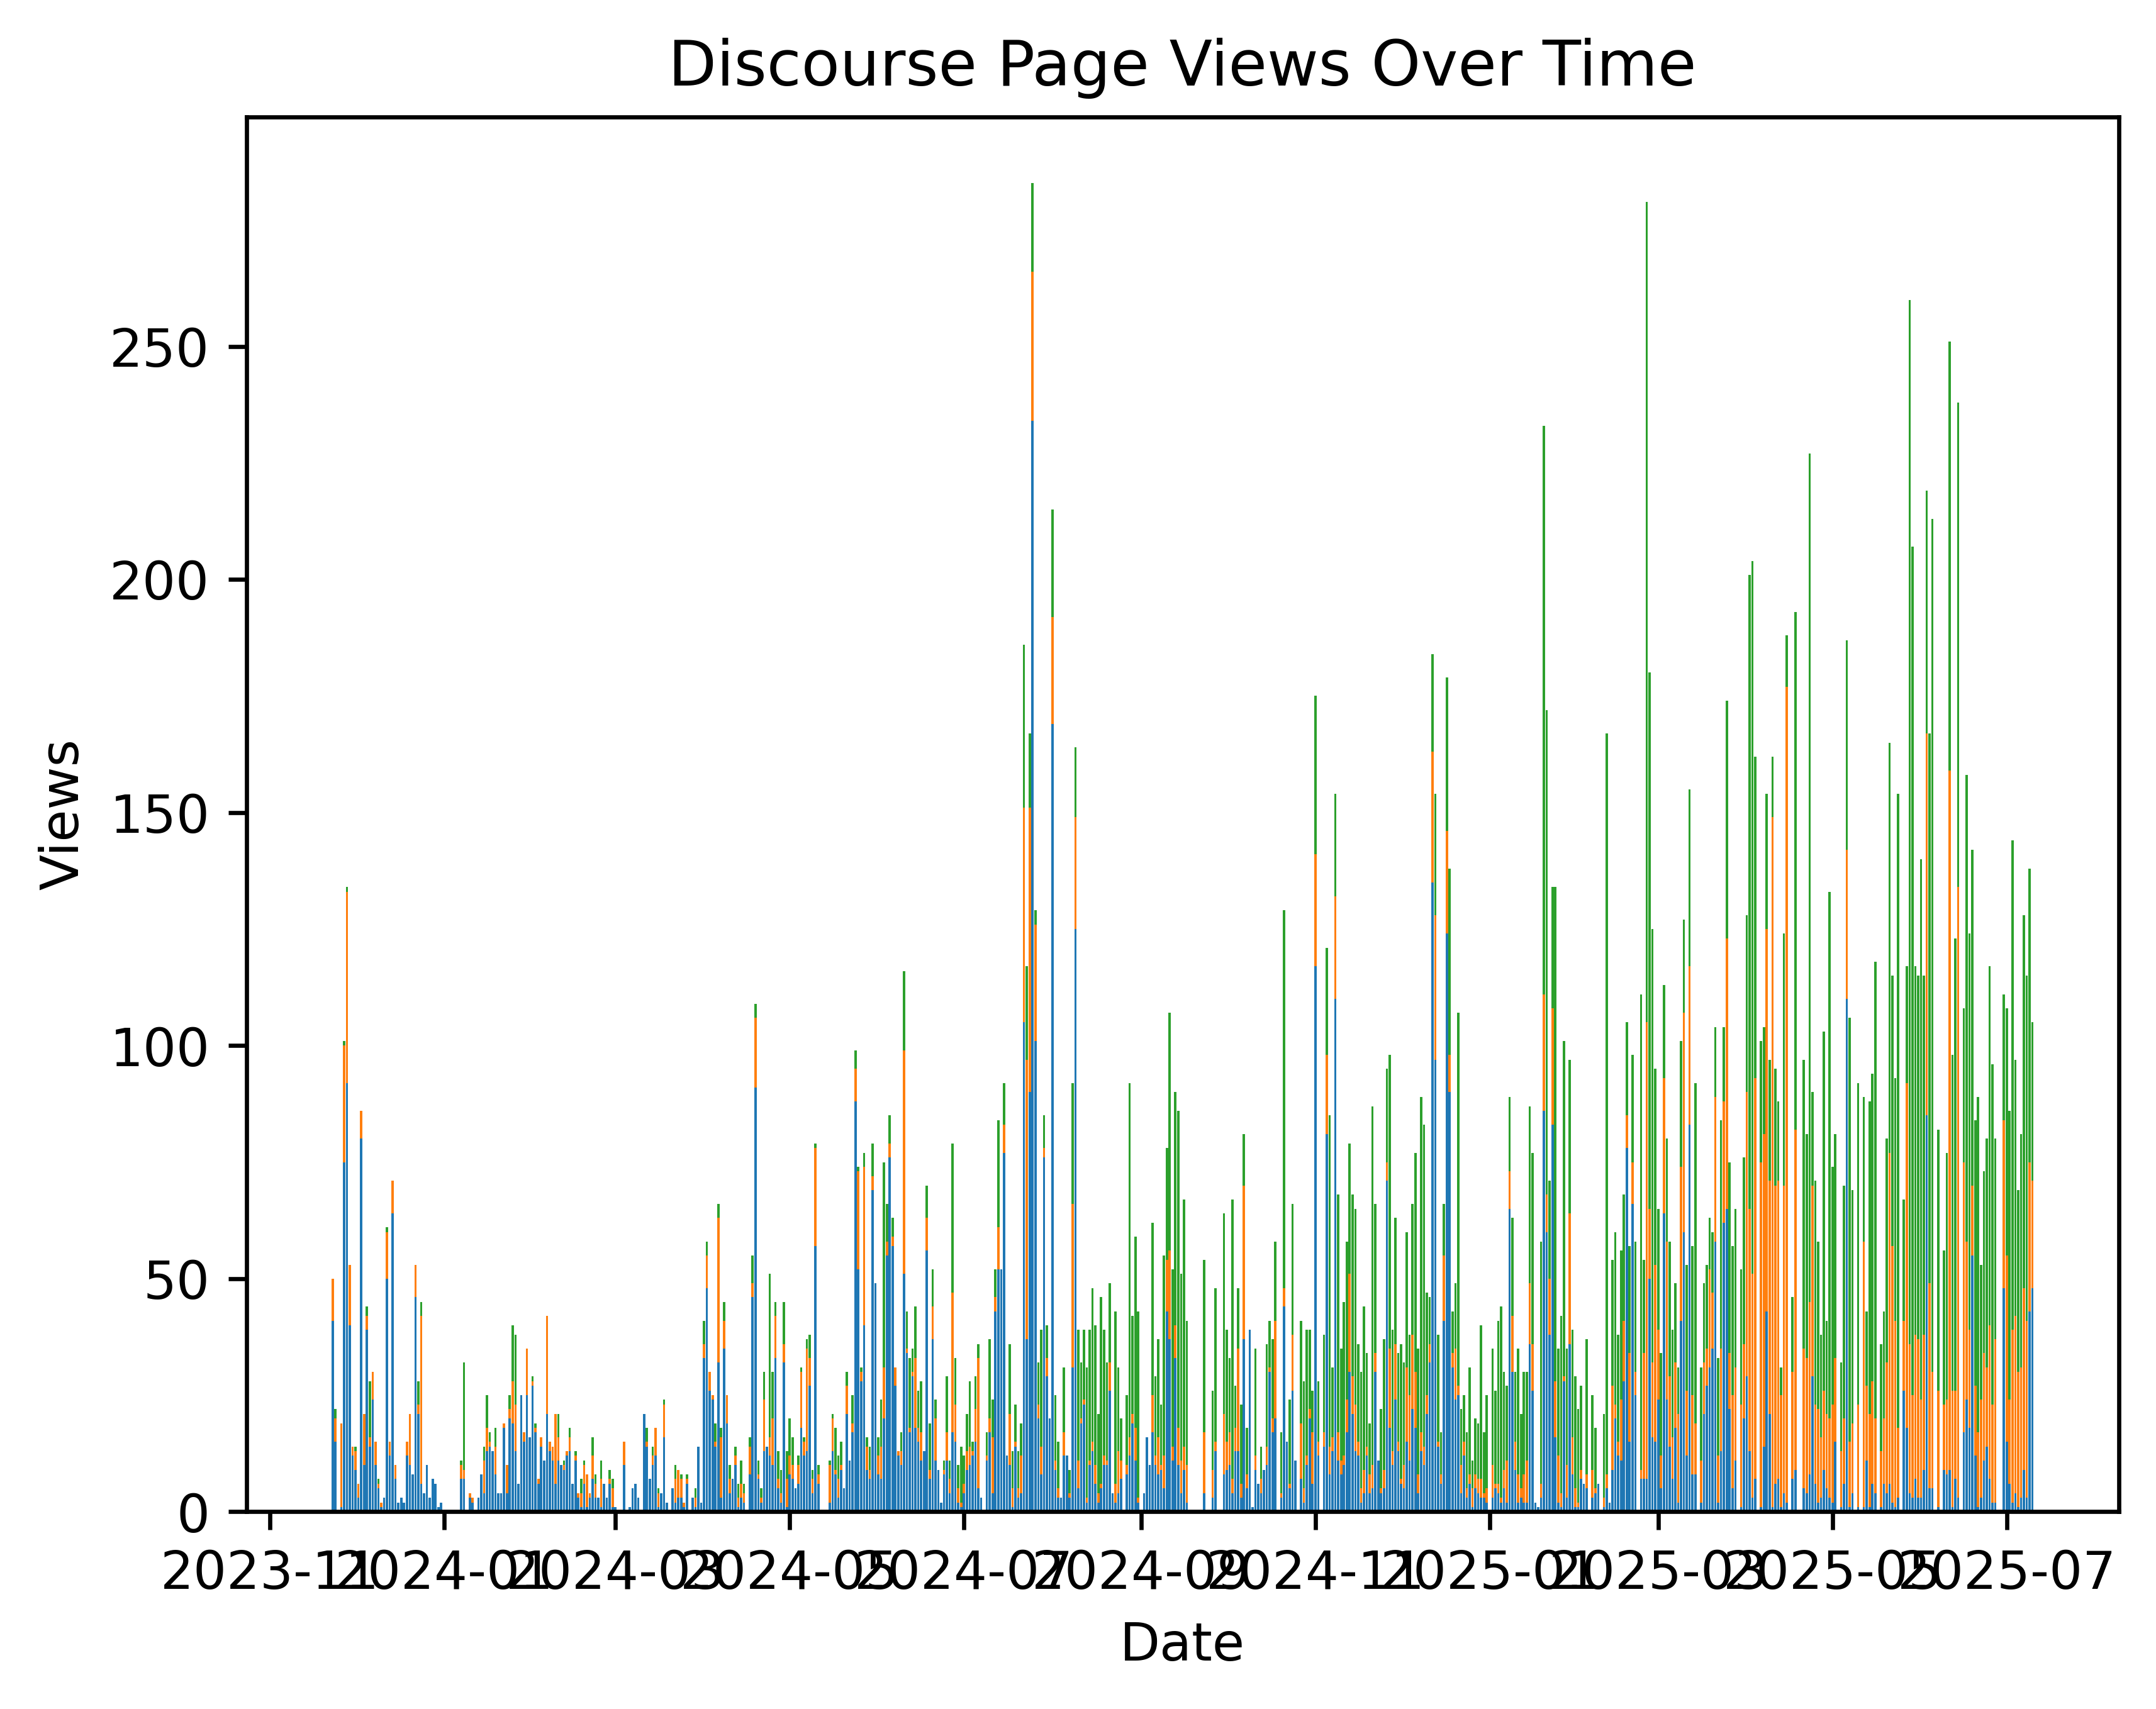

In [4]:
import matplotlib.pyplot as plt
plt.figure(dpi=600)

# plot the data
plt.bar(discourse_page_views['Day'], discourse_page_views['Logged in users'])
plt.bar(discourse_page_views['Day'], discourse_page_views['Anonymous users'], bottom=discourse_page_views['Logged in users'])
plt.bar(discourse_page_views['Day'], discourse_page_views['Crawlers'], bottom=discourse_page_views['Logged in users'] + discourse_page_views['Anonymous users'])

plt.title('Discourse Page Views Over Time')
plt.xlabel('Date')
plt.ylabel('Views')
plt.show()

In [5]:
# group by week and sum the views
discourse_page_views['Week'] = discourse_page_views['Day'].dt.to_period('W')
discourse_page_views['Week']

0      2023-11-20/2023-11-26
1      2023-11-20/2023-11-26
2      2023-11-20/2023-11-26
3      2023-11-27/2023-12-03
4      2023-11-27/2023-12-03
               ...          
586    2024-02-26/2024-03-03
587    2024-03-04/2024-03-10
588    2024-08-26/2024-09-01
589    2024-09-16/2024-09-22
590    2024-09-16/2024-09-22
Name: Week, Length: 591, dtype: period[W-SUN]

In [6]:
# sum the views by week (only numeric columns)
weekly_views = discourse_page_views.groupby('Week')[['Logged in users', 'Anonymous users', 'Crawlers']].sum().reset_index()
weekly_views

,Week,Logged in users,Anonymous users,Crawlers
0,2023-11-20/2023-11-26,57.0,32.0,2.0
1,2023-11-27/2023-12-03,311.0,94.0,3.0
2,2023-12-04/2023-12-10,103.0,29.0,15.0
3,2023-12-11/2023-12-17,141.0,23.0,1.0
4,2023-12-18/2023-12-24,105.0,59.0,10.0
...,...,...,...,...
81,2025-06-09/2025-06-15,37.0,374.0,516.0
82,2025-06-16/2025-06-22,130.0,180.0,448.0
83,2025-06-23/2025-06-29,36.0,163.0,319.0
84,2025-06-30/2025-07-06,79.0,226.0,391.0


In [7]:
# make a new column for the week start date
weekly_views['Week Start'] = weekly_views['Week'].dt.start_time

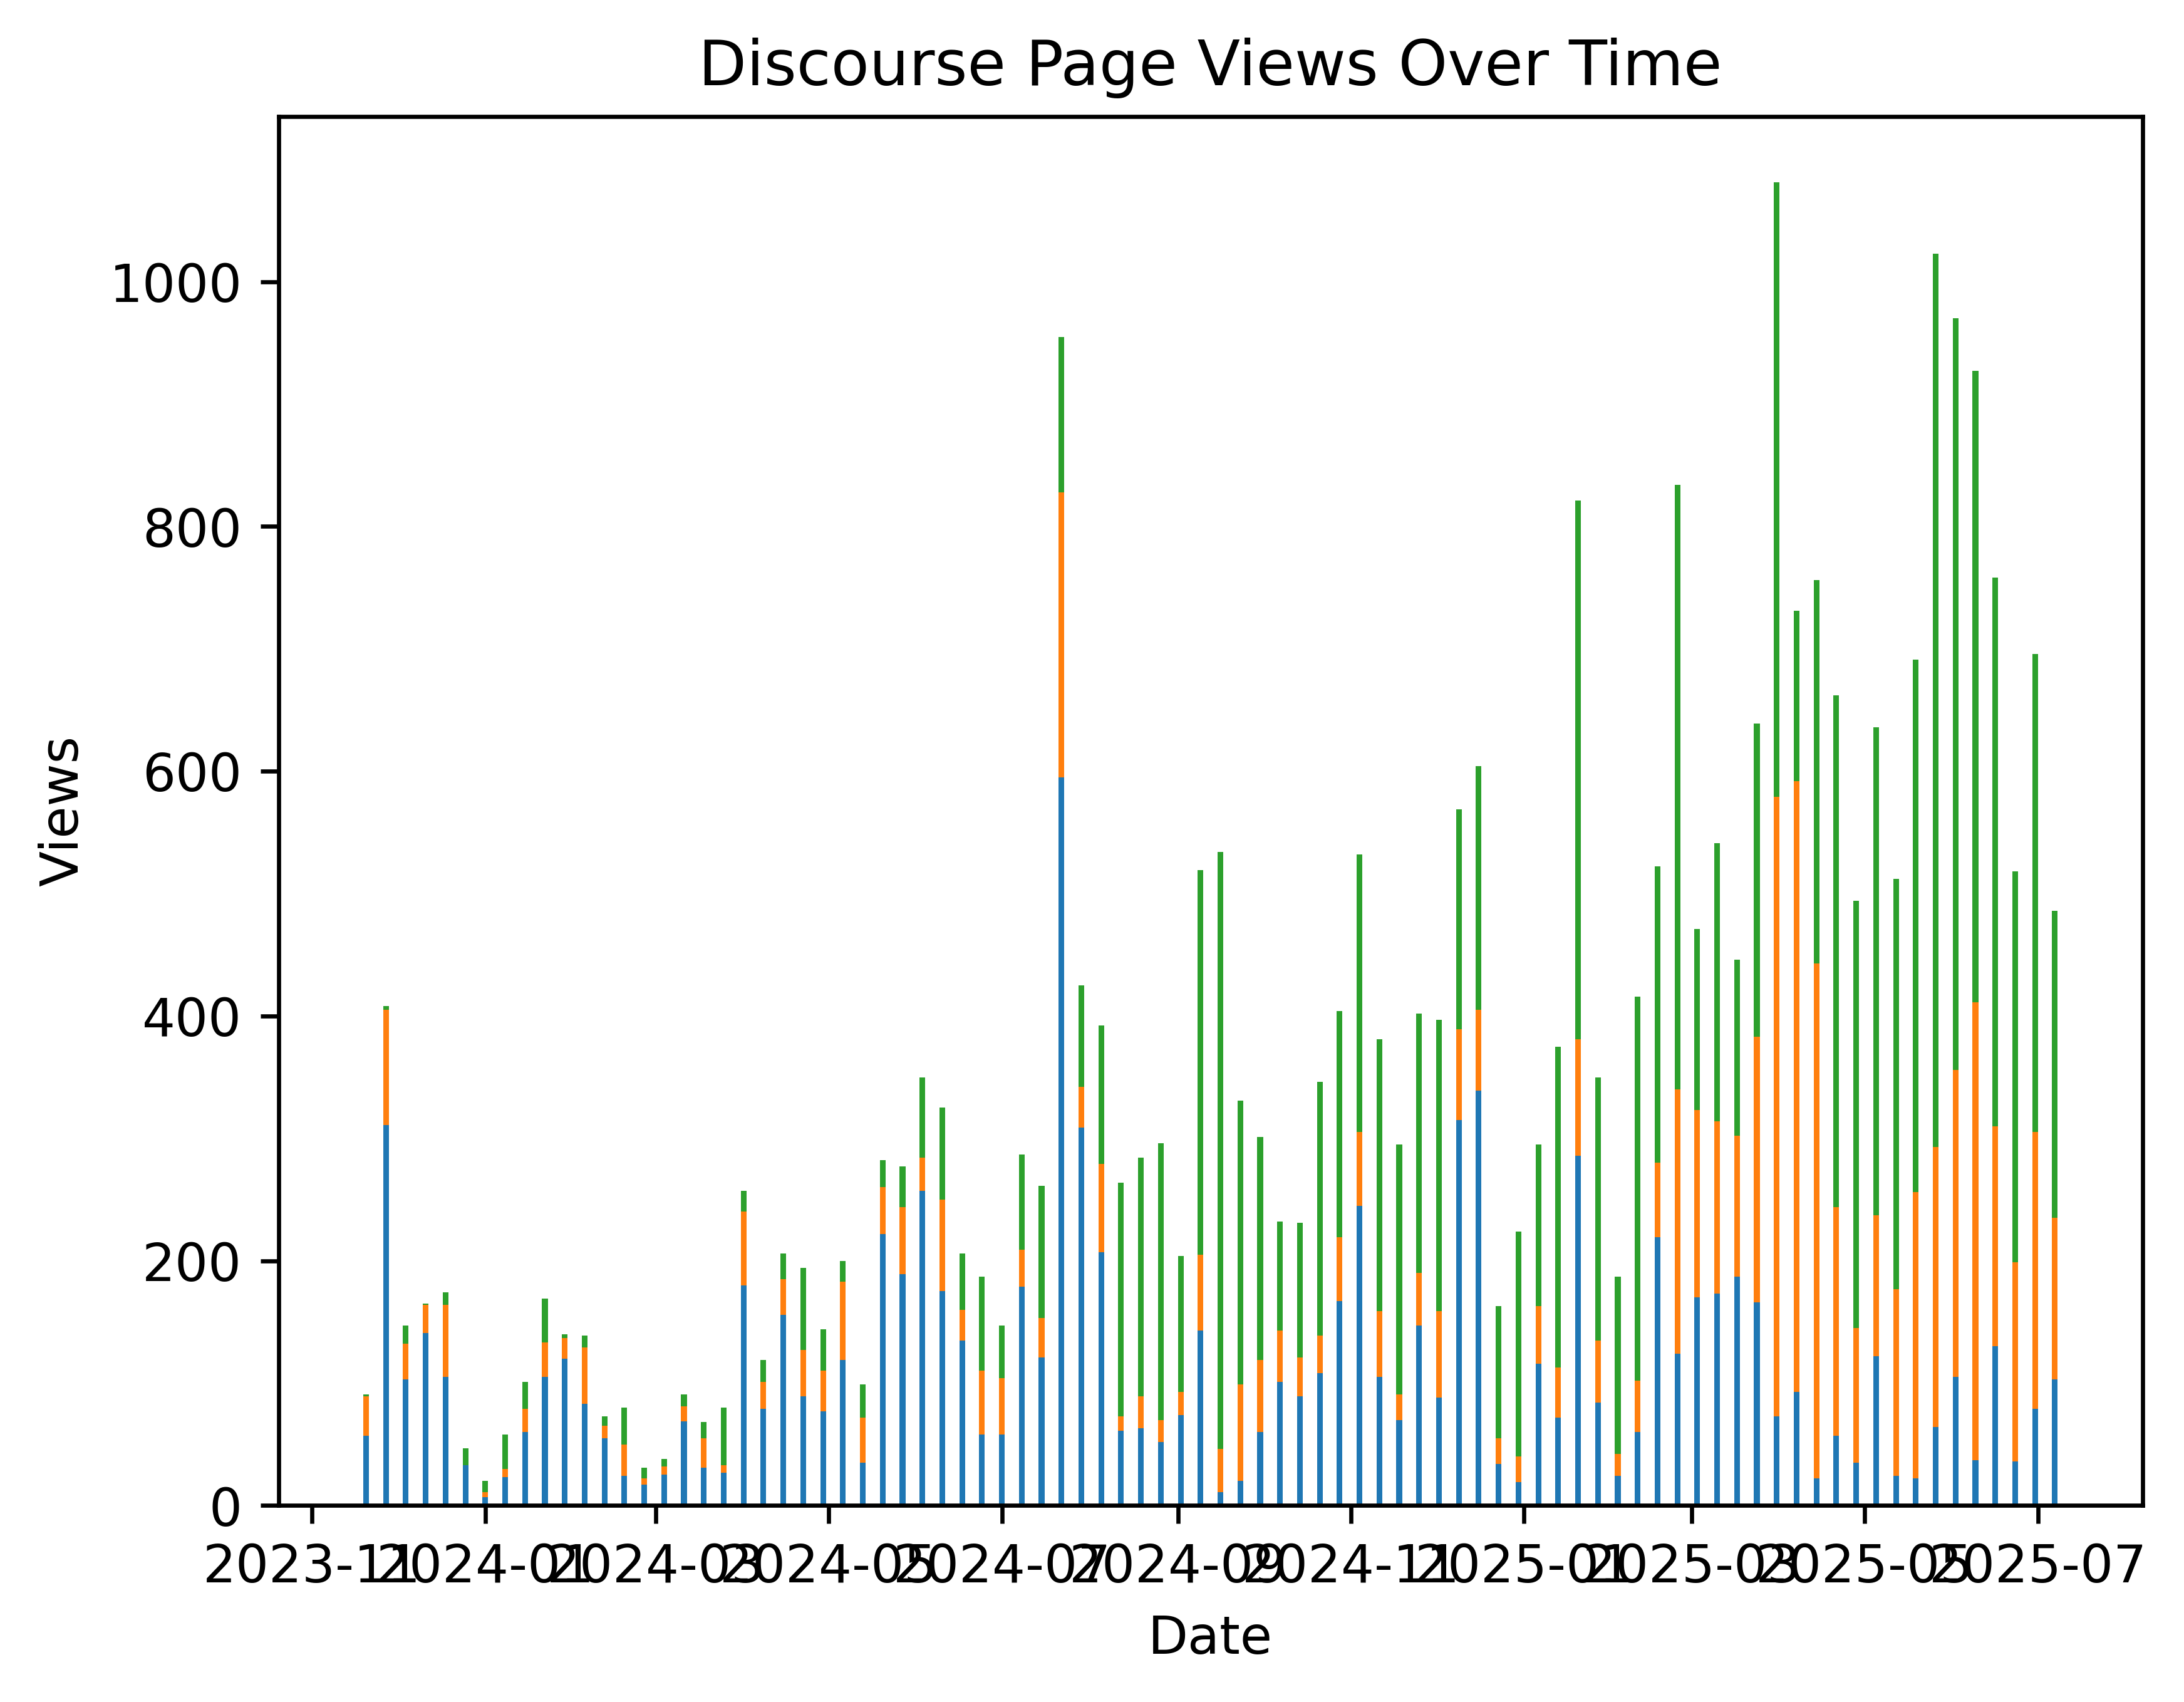

In [8]:
plt.figure(dpi=600)
# plot the data
plt.bar(weekly_views["Week Start"], weekly_views['Logged in users'], width=2)
plt.bar(weekly_views["Week Start"], weekly_views['Anonymous users'], width=2, bottom=weekly_views['Logged in users'])
plt.bar(weekly_views["Week Start"], weekly_views['Crawlers'], width=2, bottom=weekly_views['Logged in users'] + weekly_views['Anonymous users'])

plt.title('Discourse Page Views Over Time')
plt.xlabel('Date')
plt.ylabel('Views')
plt.show()

## Star history

In [9]:
star_df = pandas.read_csv('star-history-2025710.csv')
star_df.head()

,Repository,Date,Stars
0,festim-dev/FESTIM,Mon Dec 13 2021 15:33:01 GMT-0500 (Eastern Sta...,1
1,festim-dev/FESTIM,Mon Aug 08 2022 18:30:23 GMT-0400 (Eastern Day...,8
2,festim-dev/FESTIM,Sun Oct 23 2022 04:21:00 GMT-0400 (Eastern Day...,15
3,festim-dev/FESTIM,Sun Jul 09 2023 10:12:28 GMT-0400 (Eastern Day...,22
4,festim-dev/FESTIM,Sun Jul 09 2023 11:41:57 GMT-0400 (Eastern Day...,29


In [10]:
# convert 'Date' to datetime
# format is Mon Dec 13 2021 15:33:01 GMT-0500 (Eastern Standard Time)
# We'll parse up to the GMT offset and ignore the timezone name in parentheses

import re

def parse_date_with_timezone(date_str):
    # Remove the timezone name in parentheses
    date_str_cleaned = re.sub(r'\s*\([^)]+\)$', '', date_str)
    return pandas.to_datetime(date_str_cleaned, format='%a %b %d %Y %H:%M:%S GMT%z')

star_df['Date'] = star_df['Date'].apply(parse_date_with_timezone)
star_df.head()

,Repository,Date,Stars
0,festim-dev/FESTIM,2021-12-13 15:33:01-05:00,1
1,festim-dev/FESTIM,2022-08-08 18:30:23-04:00,8
2,festim-dev/FESTIM,2022-10-23 04:21:00-04:00,15
3,festim-dev/FESTIM,2023-07-09 10:12:28-04:00,22
4,festim-dev/FESTIM,2023-07-09 11:41:57-04:00,29


In [11]:
# derivative of the stars nb stars per month
star_df['Stars Change'] = star_df['Stars'].diff().fillna(0)
# Calculate days difference and convert to months (assuming 30.44 days per month on average)
days_difference = star_df['Date'].diff().dt.days
month_difference = days_difference / 30.44
star_df['Stars Change'] /= month_difference

/home/remidm/anaconda3/envs/pose-env/lib/python3.13/site-packages/matplotlib/transforms.py:2436: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


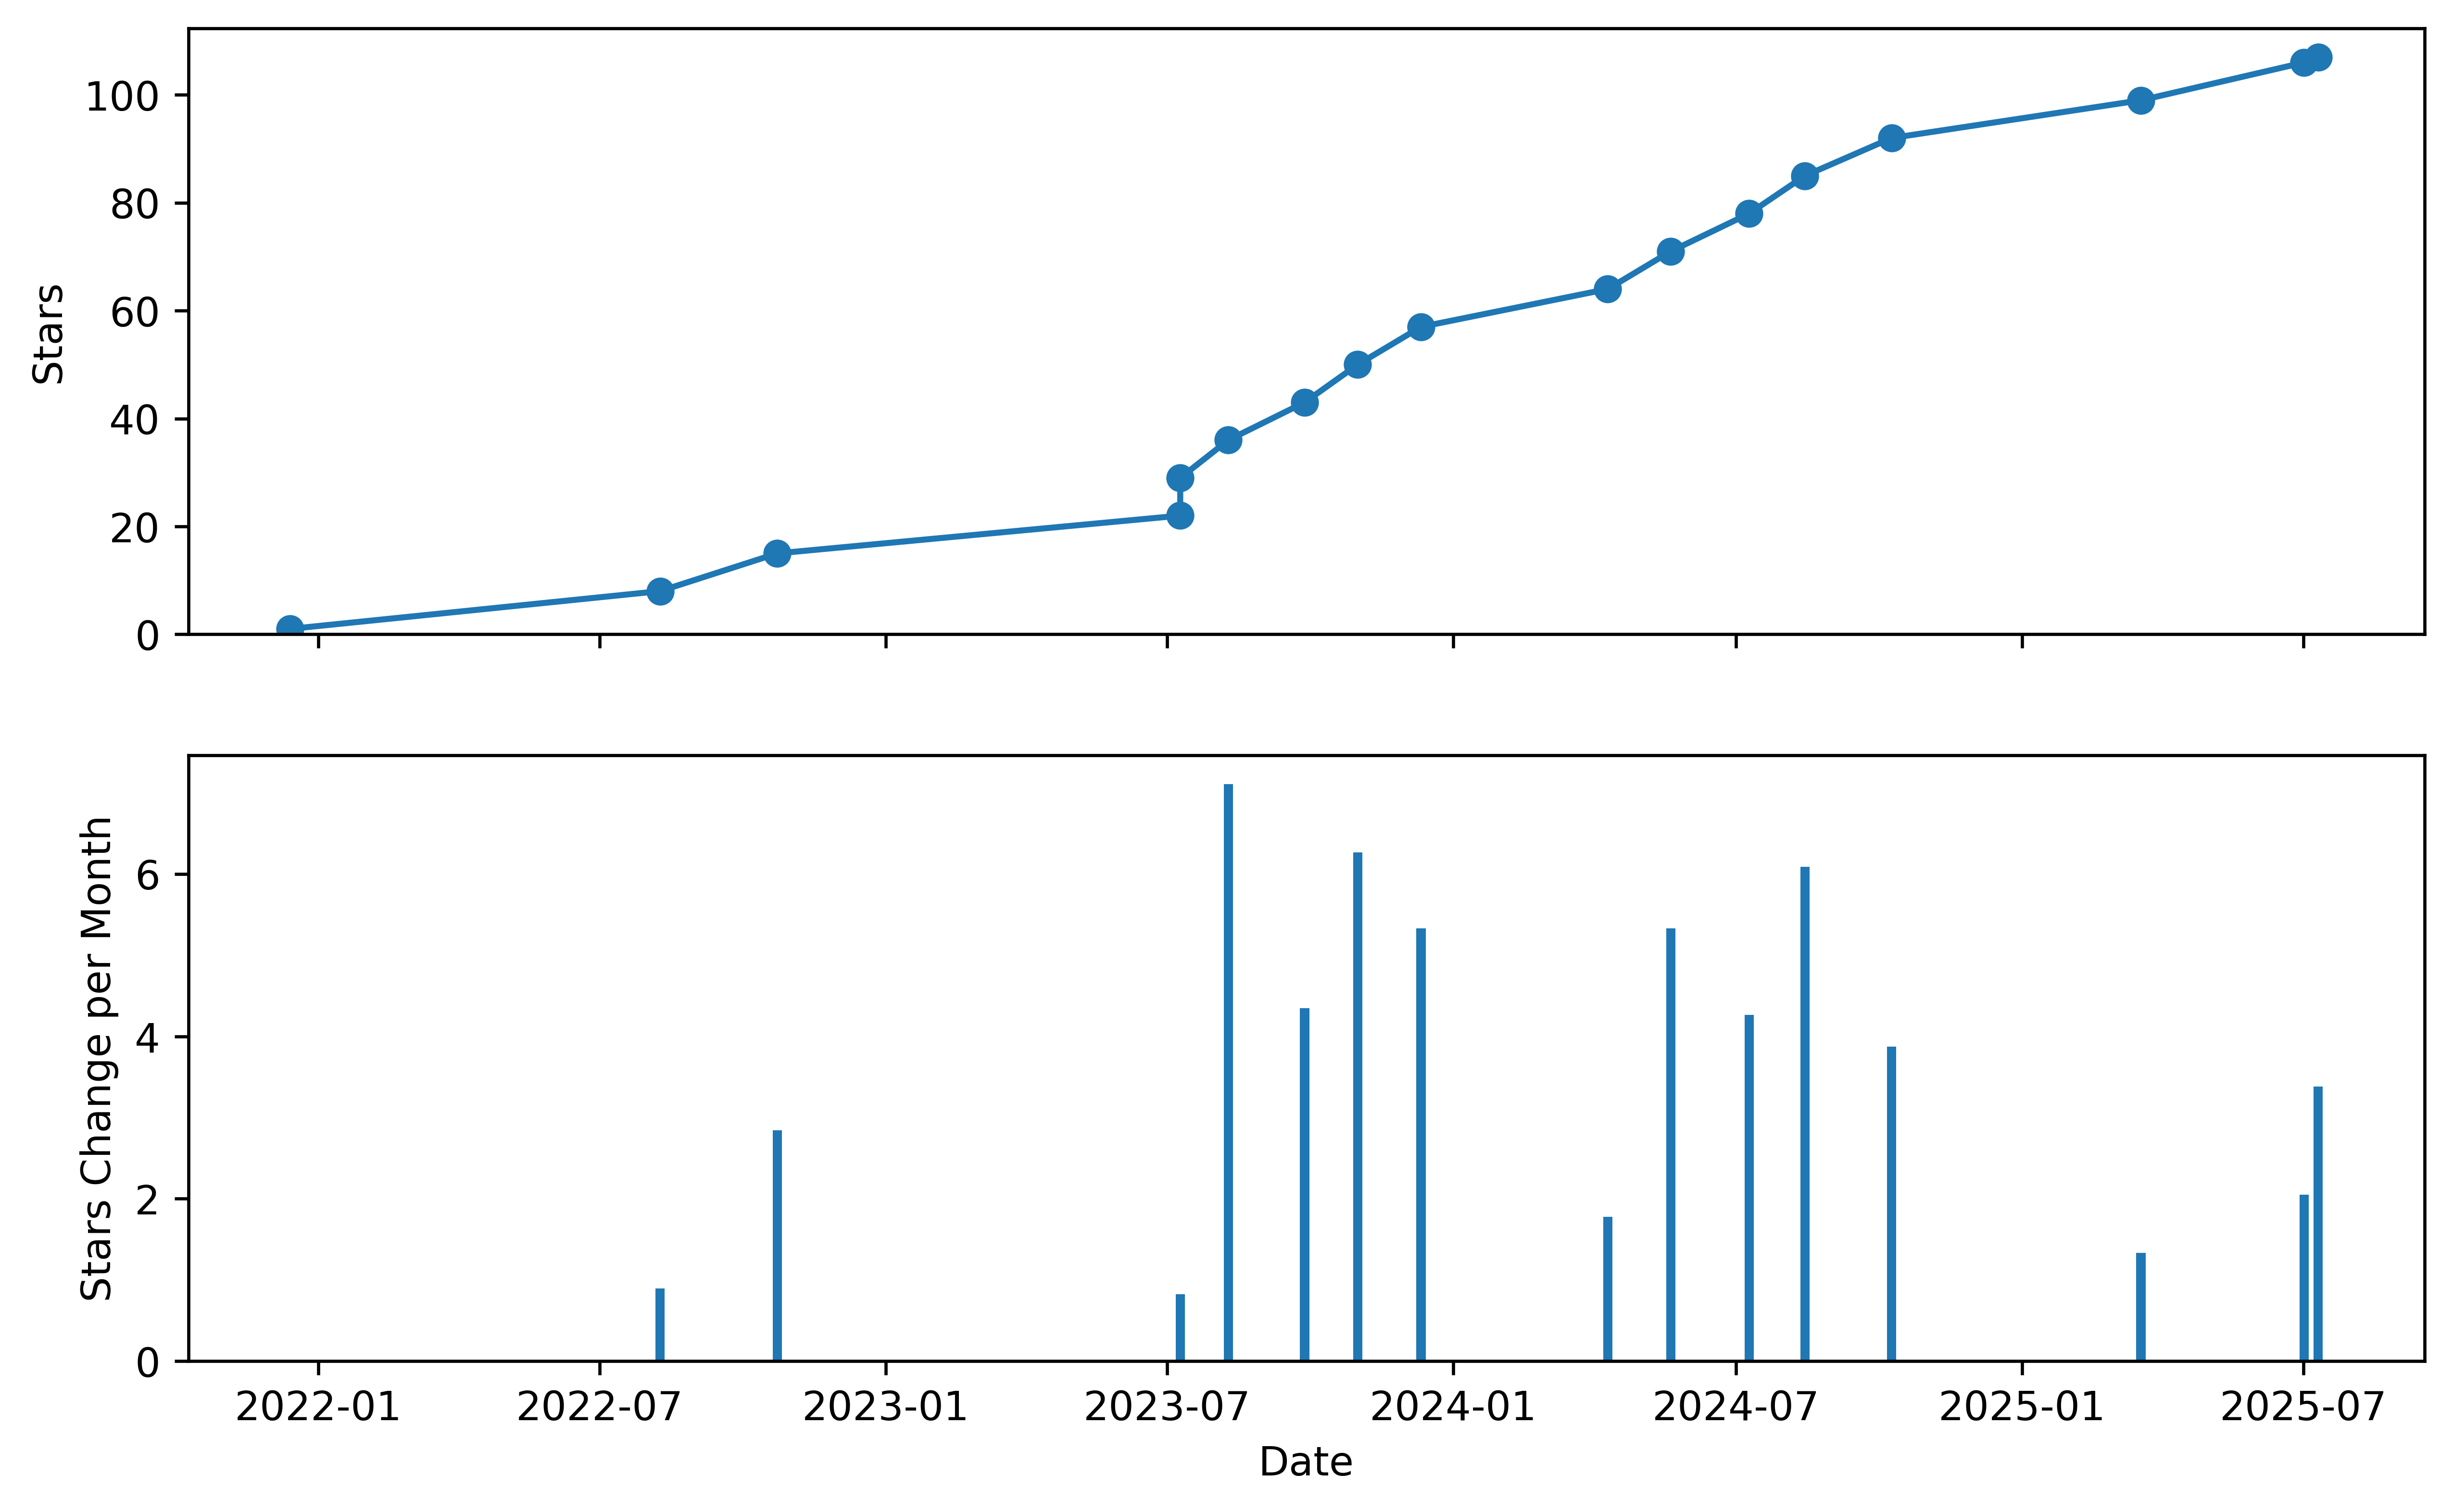

In [12]:
# plot the data
fig, axs = plt.subplots(figsize=(10, 6), dpi=600, nrows=2, sharex=True)
axs[0].plot(star_df['Date'], star_df['Stars'], marker='o', linestyle='-')
axs[0].set_ylim(bottom=0)
axs[0].set_ylabel('Stars')
axs[1].bar(star_df['Date'], star_df['Stars Change'], width=6)
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Stars Change per Month')

plt.show()